In [2]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().mean() * 100).round(2))

Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing Value Percentage:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp         

In [4]:
print("Descriptive Statistics:")
display(df.describe())

print("\nSurvival Counts:")
print(df["survived"].value_counts())

print("\nSurvival Percentages:")
print((df["survived"].value_counts(normalize=True) * 100).round(2))

print("\nSurvival by Sex:")
print(pd.crosstab(df["sex"], df["survived"]))

print("\nSurvival by Passenger Class:")
print(pd.crosstab(df["pclass"], df["survived"]))

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Survival Counts:
survived
0    549
1    342
Name: count, dtype: int64

Survival Percentages:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Survival by Sex:
survived    0    1
sex               
female     81  233
male      468  109

Survival by Passenger Class:
survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


In [5]:
numeric_cols = ["age", "fare", "sibsp", "parch"]

outlier_results = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

print("Fare skewness:", df["fare"].skew())

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,20.1250,38.0,17.8750,-6.6875,64.8125,11
1,fare,7.9104,31.0,23.0896,-26.7240,65.6344,116
2,sibsp,0.0000,1.0,1.0000,-1.5000,2.5000,46
3,parch,0.0000,0.0,0.0000,0.0000,0.0000,213


Fare skewness: 4.787316519674893


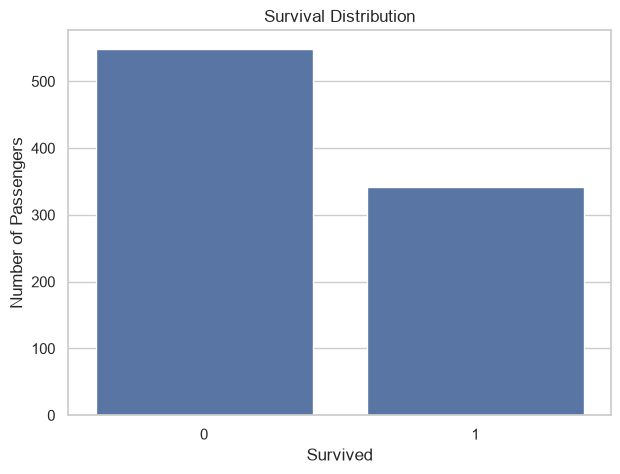

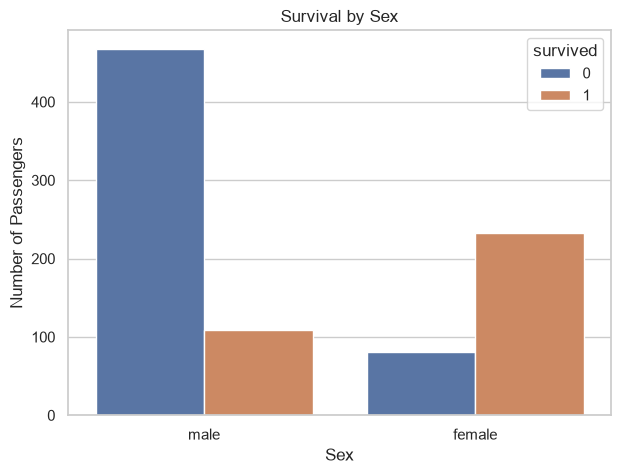

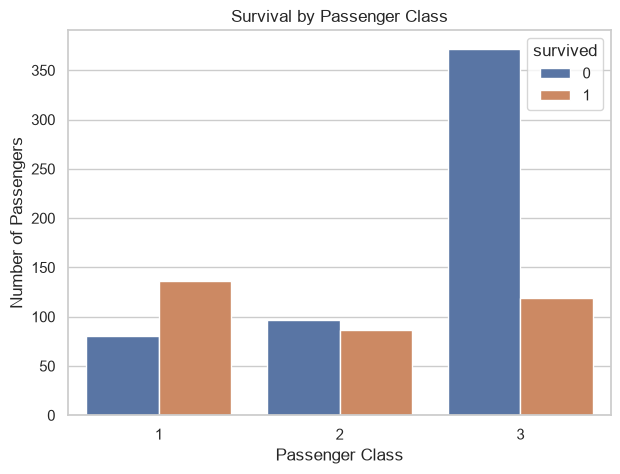

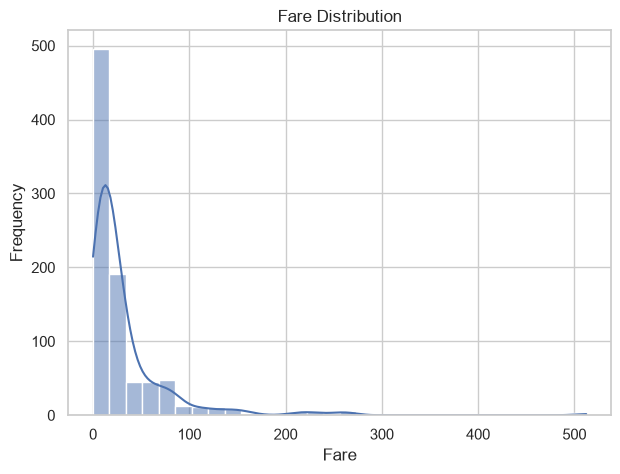

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.savefig("charts/survival_distribution.png", bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.savefig("charts/survival_by_sex.png", bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.savefig("charts/survival_by_class.png", bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.savefig("charts/fare_distribution.png", bbox_inches="tight")
plt.show()

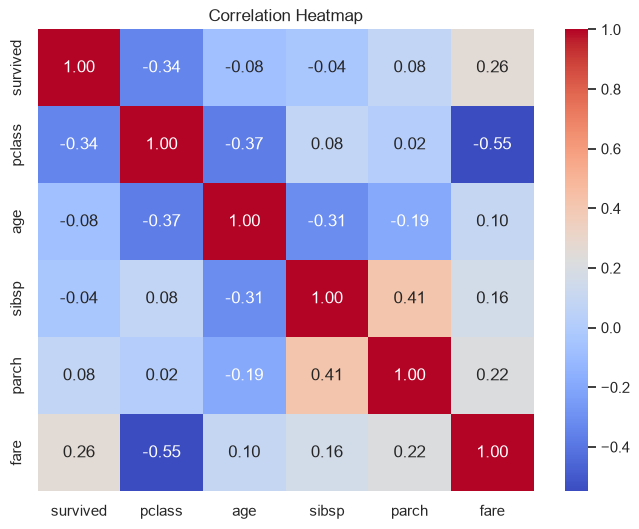

In [8]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

## EDA Interpretations

### 1. Survival Distribution
The dataset contains more passengers who did not survive than passengers who survived. This shows that the target variable is imbalanced, with the non-survivor class being larger.

### 2. Survival by Sex
Female passengers had a substantially higher survival rate than male passengers. Sex therefore appears to be an important feature for predicting survival.

### 3. Survival by Passenger Class
Survival varies across passenger classes. First-class passengers had a higher proportion of survivors, while third-class passengers had a lower proportion of survivors.

### 4. Fare Distribution
The fare distribution is strongly right-skewed. Most passengers paid relatively lower fares, while a smaller number of passengers paid substantially higher fares. This is consistent with the high positive fare skewness observed during the statistical analysis.

### 5. Correlation Heatmap
The correlation heatmap shows the relationships among survived, pclass, age, sibsp, parch, and fare. Passenger class has a negative relationship with survival, while fare has a positive relationship with survival. The remaining numerical features show weaker relationships with the target compared with these variables.

In [9]:
from sklearn.model_selection import train_test_split

data = pd.read_csv("titanic.csv")

target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 7)
X_test shape: (179, 7)
y_train shape: (712,)
y_test shape: (179,)


In [10]:
print("Training missing values:")
print(X_train.isnull().sum())

print("\nTest missing values:")
print(X_test.isnull().sum())

Training missing values:
pclass        0
sex           0
age         137
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

Test missing values:
pclass       0
sex          0
age         40
sibsp        0
parch        0
fare         0
embarked     0
dtype: int64


In [11]:
X_train = X_train.copy()
X_test = X_test.copy()

age_median = X_train["age"].median()
embarked_mode = X_train["embarked"].mode()[0]

X_train["age"] = X_train["age"].fillna(age_median)
X_test["age"] = X_test["age"].fillna(age_median)

X_train["embarked"] = X_train["embarked"].fillna(embarked_mode)
X_test["embarked"] = X_test["embarked"].fillna(embarked_mode)

print("Training missing values:")
print(X_train.isnull().sum())

print("\nTest missing values:")
print(X_test.isnull().sum())

Training missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Test missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

X_train_encoded = pd.get_dummies(
    X_train,
    columns=["sex", "embarked"],
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["sex", "embarked"],
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]

scaler = StandardScaler()

X_train_encoded[numeric_features] = scaler.fit_transform(
    X_train_encoded[numeric_features]
)

X_test_encoded[numeric_features] = scaler.transform(
    X_test_encoded[numeric_features]
)

print("Training shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Training shape: (712, 8)
Test shape: (179, 8)


In [13]:
X_train = X_train.copy()
X_test = X_test.copy()

age_median = X_train["age"].median()
embarked_mode = X_train["embarked"].mode()[0]

X_train["age"] = X_train["age"].fillna(age_median)
X_test["age"] = X_test["age"].fillna(age_median)

X_train["embarked"] = X_train["embarked"].fillna(embarked_mode)
X_test["embarked"] = X_test["embarked"].fillna(embarked_mode)

print("Training missing values:")
print(X_train.isnull().sum())

print("\nTest missing values:")
print(X_test.isnull().sum())

Training missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Test missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

X_train_encoded = pd.get_dummies(
    X_train,
    columns=["sex", "embarked"],
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["sex", "embarked"],
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]

scaler = StandardScaler()

X_train_encoded[numeric_features] = scaler.fit_transform(
    X_train_encoded[numeric_features]
)

X_test_encoded[numeric_features] = scaler.transform(
    X_test_encoded[numeric_features]
)

print("Training shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Training shape: (712, 8)
Test shape: (179, 8)


In [15]:
import numpy as np

print("Means:")
print(np.round(X_train_encoded[numeric_features].mean(), 3))

print("\nStandard deviations:")
print(np.round(X_train_encoded[numeric_features].std(), 3))

Means:
pclass   -0.0
age       0.0
sibsp    -0.0
parch    -0.0
fare     -0.0
dtype: float64

Standard deviations:
pclass    1.001
age       1.001
sibsp     1.001
parch     1.001
fare      1.001
dtype: float64


In [16]:
X_train_encoded = X_train_encoded.fillna(X_train_encoded.median())
X_test_encoded = X_test_encoded.fillna(X_train_encoded.median())

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_encoded)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.821229,0.793651,0.724638,0.757576
2,Random Forest,0.810056,0.769231,0.724638,0.746269


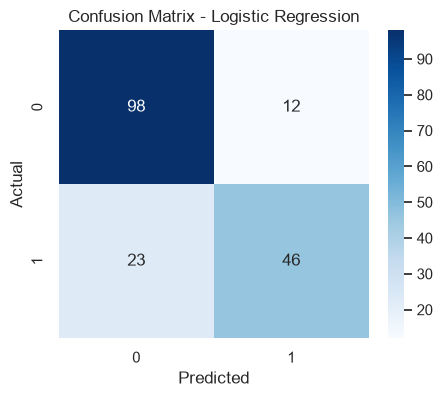

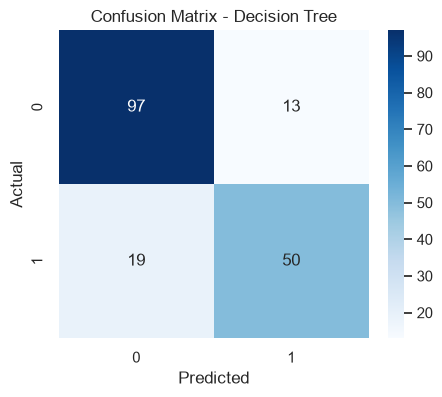

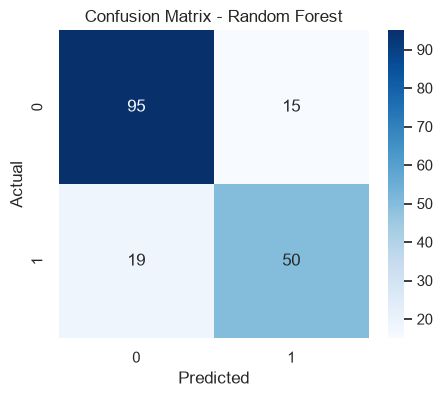

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test_encoded)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [20]:
results_df.to_csv("model_results.csv", index=False)

print("Model evaluation results saved successfully")

Model evaluation results saved successfully


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
4,fare,0.276694
5,sex_male,0.262526
1,age,0.255762
0,pclass,0.079391
2,sibsp,0.052899
3,parch,0.040215
7,embarked_S,0.022759
6,embarked_Q,0.009755


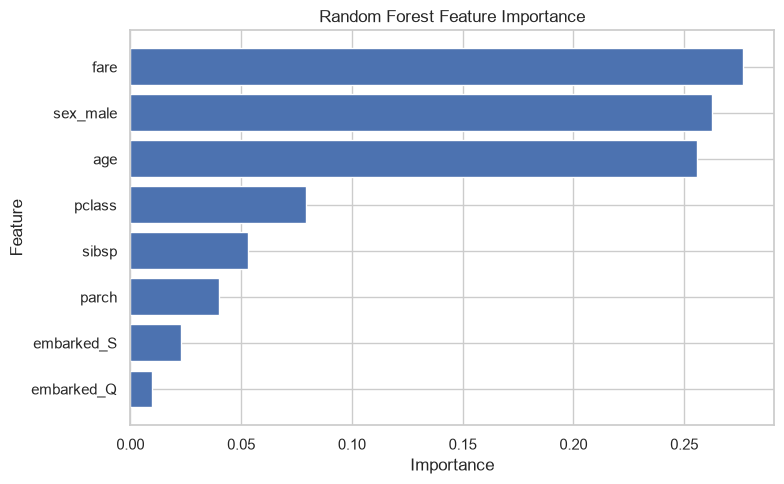

In [22]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("charts/random_forest_feature_importance.png")
plt.show()

In [23]:
import joblib

joblib.dump(X_train_encoded, "X_train_encoded.joblib")
joblib.dump(y_train, "y_train.joblib")

print("Training data saved successfully")

Training data saved successfully
